[bank_lgbm] Loaded train: (27128, 18)
[bank_lgbm] Loaded test:  (18083, 17)
[bank_lgbm] Loaded sample (header=None): (18083, 2)
[bank_lgbm] Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
[bank_lgbm] Numeric columns:     ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Training until validation scores don't improve for 200 rounds
[200]	train's auc: 0.959559	valid's auc: 0.933045
[400]	train's auc: 0.976356	valid's auc: 0.932854
Early stopping, best iteration is:
[237]	train's auc: 0.963413	valid's auc: 0.933222
[bank_lgbm] Fold 1 AUC: 0.933222  | best_iter=237
Training until validation scores don't improve for 200 rounds
[200]	train's auc: 0.959007	valid's auc: 0.93413
[400]	train's auc: 0.975864	valid's auc: 0.933945
Early stopping, best iteration is:
[235]	train's auc: 0.962412	valid's auc: 0.934543
[bank_lgbm] Fold 2 AUC: 0.934543  | best_iter=235
Training until validation scores don't improve f

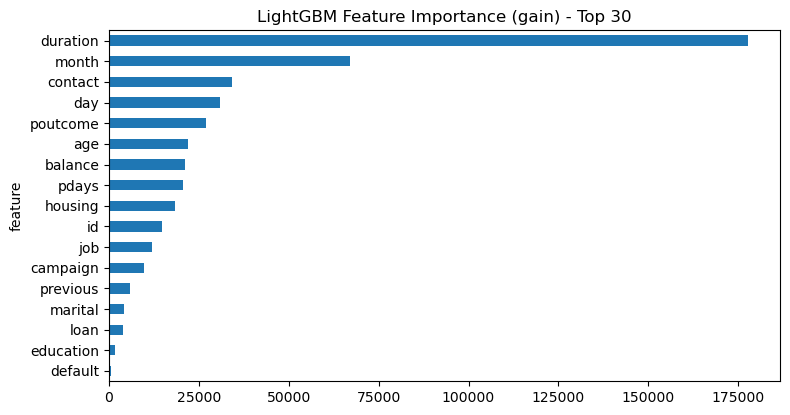

In [ ]:

import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from typing import Tuple, List, Dict, Optional

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# Optional: plotting for feature importance if matplotlib is available
try:
    import matplotlib.pyplot as plt
    _HAVE_MPL = True
except Exception:
    _HAVE_MPL = False

# LightGBM is optional at runtime of this template
try:
    import lightgbm as lgb
    _HAVE_LGB = True
except Exception as e:
    _HAVE_LGB = False
    _LGB_ERR = e

RANDOM_STATE = 82

def _print(msg: str):
    print(f"[bank_lgbm] {msg}")

def load_data(
    train_path: str = "train.csv",
    test_path: str = "test.csv",
    sample_path: str = "submit_sample.csv",
):
    """Load CSVs; read sample with header=None to match tutorial submission behavior."""
    def _safe_read(p, **kw):
        p = Path(p)
        if p.exists():
            return pd.read_csv(p, **kw)
        return None

    train_df = _safe_read(train_path)
    test_df = _safe_read(test_path)
    sample_df = _safe_read(sample_path, header=None)  # tutorial: headerless

    if train_df is None:
        _print(f"train.csv not found at '{train_path}'.")
    else:
        _print(f"Loaded train: {train_df.shape}")
    if test_df is None:
        _print(f"test.csv not found at '{test_path}'.")
    else:
        _print(f"Loaded test:  {test_df.shape}")
    if sample_df is None:
        _print(f"submit_sample.csv not found at '{sample_path}'.")
    else:
        _print(f"Loaded sample (header=None): {sample_df.shape}")

    return train_df, test_df, sample_df


def identify_columns(
    df: pd.DataFrame,
    target_col_name: str = "y",
    min_numeric_share: float = 0.95,
) -> Tuple[List[str], List[str], str]:
    """
    列の役割をざっくり推定して返す（idは固定で 'id'）。
    - id列: 'id'（存在チェックあり）
    - 目的変数: デフォルト 'y'（存在チェックあり）
    - 数値列: すでに数値型 もしくは 95%以上が数値に変換できる列
    - カテゴリ列: 上記以外
    """
    id_col = "id"

    target_col = target_col_name

    feature_cols = [c for c in df.columns if c not in {id_col, target_col}]

    cat_cols: List[str] = []
    num_cols: List[str] = []

    for c in feature_cols:
        s = df[c]

        # 既に数値型ならそのまま数値扱い
        if pd.api.types.is_numeric_dtype(s):
            num_cols.append(c)
            continue

        # 文字列などは「数値にできるか」を判定（例: "123", "45.6" はOK）
        s_num = pd.to_numeric(s, errors="coerce")
        if s_num.notna().mean() >= min_numeric_share:
            num_cols.append(c)
        else:
            cat_cols.append(c)

    return cat_cols, num_cols, id_col

def prepare_features(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, List[str], Optional[str]]:
    """Prepare X, y, X_test with minimal touch, using all provided features (native categoricals for LightGBM)."""
    cat_cols, num_cols, id_col = identify_columns(train_df)

    # Use ALL features (numeric + categorical) as-is
    train_df, test_df = align_categorical(train_df.copy(), test_df.copy(), cat_cols)

    y = train_df["y"].astype(int)
    X = train_df.drop(columns=["y"])
    X_test = test_df.copy()

    _print(f"Categorical columns: {cat_cols}")
    _print(f"Numeric columns:     {num_cols}")
    return X, y, X_test, cat_cols, id_col

def default_lgb_params(pos_weight: Optional[float] = None) -> Dict:
    params = dict(
        objective="binary",
        metric="auc",
        boosting="gbdt",
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        min_data_in_leaf=30,
        lambda_l1=0.0,
        lambda_l2=1.0,
        n_jobs=-1,
        verbose=-1,
        seed=RANDOM_STATE,
        feature_fraction_bynode=0.8,
    )
    if pos_weight is not None:
        params["scale_pos_weight"] = pos_weight
    return params

def train_cv(
    X: pd.DataFrame,
    y: pd.Series,
    X_test: pd.DataFrame,
    cat_cols: List[str],
    n_splits: int = 5,
    seed: int = RANDOM_STATE,
    params: Optional[Dict] = None,
    num_boost_round: int = 10000,
    early_stopping_rounds: int = 200,
):
    if not _HAVE_LGB:
        raise RuntimeError(f"LightGBM not available: {_LGB_ERR}")

    if params is None:
        pos = y.sum()
        neg = y.shape[0] - pos
        pos_weight = float(neg) / float(pos) if pos > 0 else None
        params = default_lgb_params(pos_weight=pos_weight)

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    oof = np.zeros(len(X), dtype=float)
    test_pred = np.zeros(len(X_test), dtype=float)
    feature_importances = []

    for fold, (trn_idx, val_idx) in enumerate(kf.split(X, y), 1):
        X_trn, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_trn, y_val = y.iloc[trn_idx], y.iloc[val_idx]

        train_set = lgb.Dataset(X_trn, label=y_trn, categorical_feature=cat_cols, free_raw_data=False)
        valid_set = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols, free_raw_data=False)

        model = lgb.train(
            params=params,
            train_set=train_set,
            num_boost_round=num_boost_round,
            valid_sets=[train_set, valid_set],
            valid_names=["train", "valid"],
            callbacks=[
                lgb.early_stopping(stopping_rounds=early_stopping_rounds),
                lgb.log_evaluation(period=200),
            ],
        )

        oof[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
        fold_auc = roc_auc_score(y_val, oof[val_idx])
        _print(f"Fold {fold} AUC: {fold_auc:.6f}  | best_iter={model.best_iteration}")

        test_pred += model.predict(X_test, num_iteration=model.best_iteration) / n_splits

        fi = pd.DataFrame({
            "feature": X.columns,
            "importance": model.feature_importance(importance_type="gain"),
            "fold": fold
        })
        feature_importances.append(fi)

    oof_auc = roc_auc_score(y, oof)
    _print(f"OOF AUC: {oof_auc:.6f}")

    fi_df = pd.concat(feature_importances, axis=0, ignore_index=True)
    fi_df["importance"] = fi_df["importance"].astype(float)

    return oof, test_pred, fi_df

def make_submission(
    test_pred: np.ndarray,
    test_df: pd.DataFrame,
    sample_df: Optional[pd.DataFrame],
    id_col: Optional[str],
    out_path: str = "submission_tutorial.csv"
) -> pd.DataFrame:
    """
    Match the tutorial notebook behavior ONLY for submission:
      - read submit_sample.csv with header=None (done in load_data)
      - write predictions into the second column (index 1)
      - save header=None
    """
    if sample_df is not None:
        sub = sample_df.copy()
        # ensure at least two columns
        if sub.shape[1] < 2:
            sub[1] = 0.0
        # length guard: if mismatch, try simple fixes
        if len(sub) != len(test_pred):
            _print(f"Warning: sample rows ({len(sub)}) != preds ({len(test_pred)}). Adjusting by trunc/pad.")
            if len(sub) > len(test_pred):
                sub = sub.iloc[:len(test_pred)].copy()
            else:
                # pad extra rows with zeros
                extra = pd.DataFrame({0: [None]*(len(test_pred)-len(sub)), 1: [0.0]*(len(test_pred)-len(sub))})
                sub = pd.concat([sub, extra], axis=0, ignore_index=True)
        sub.iloc[:, 1] = np.asarray(test_pred).reshape(-1)
    else:
        sub = pd.DataFrame(np.asarray(test_pred).reshape(-1))

    sub.to_csv(out_path, index=False, header=False)
    _print(f"Saved submission (tutorial style) -> {out_path}  shape={sub.shape}")
    return sub

def plot_feature_importance(fi_df: pd.DataFrame, topk: int = 30, out_path: str = "feature_importance.png"):
    fi_mean = (fi_df.groupby("feature")["importance"].mean().sort_values(ascending=False).head(topk))
    plt.figure(figsize=(8, max(4, 0.25*len(fi_mean))))
    fi_mean.iloc[::-1].plot(kind="barh")
    plt.title(f"LightGBM Feature Importance (gain) - Top {topk}")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    _print(f"Saved feature importance plot -> {out_path}")

def main():
    train_df, test_df, sample_df = load_data("train.csv", "test.csv", "submit_sample.csv")

    if (train_df is None or test_df is None):
        _print("Data files not found. Template is ready. Place train.csv/test.csv/submit_sample.csv and run again.")
        return

    if not _HAVE_LGB:
        _print(f"LightGBM is not installed in this environment: {_LGB_ERR}")
        _print("Install with: pip install lightgbm  (then rerun)")
        return

    assert "y" in train_df.columns, "train.csv must contain target column 'y'."

    X, y, X_test, cat_cols, id_col = prepare_features(train_df, test_df)

    oof, test_pred, fi_df = train_cv(X, y, X_test, cat_cols, n_splits=5, seed=RANDOM_STATE)

    Path("oof_predictions.csv").write_text(",".join(map(str, oof.tolist())))
    fi_df.to_csv("feature_importance.csv", index=False)
    _print("Saved OOF predictions -> oof_predictions.csv")
    _print("Saved feature importances -> feature_importance.csv")

    plot_feature_importance(fi_df, topk=30, out_path="feature_importance.png")

    make_submission(test_pred, X_test, sample_df, id_col, out_path="submission_lgbm.csv")

if __name__ == "__main__":
    main()


In [5]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.
